In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
!cp "/content/drive/MyDrive/5 - Temporary Files (Simple Files)/Dataset-20260716T091753Z-1-001.zip" .

In [11]:
!unzip -q Dataset-20260716T091753Z-1-001.zip -d datasets

replace datasets/Dataset/Pavements.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace datasets/Dataset/archive 15000+15000=30000.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace datasets/Dataset/archive_dpw.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace datasets/Dataset/Decks.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace datasets/Dataset/Walls.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace datasets/Dataset/archive (8).zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace datasets/Dataset/archive (8).zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: no


##Phase 1.1

In [12]:
import os
import random
import pandas as pd
from PIL import Image
from tqdm import tqdm

In [13]:
ROOT = "/content/datasets/Dataset"

DATASETS = {
    "Archive40K": os.path.join(ROOT, "archive (8)"),
    "Archive30K": os.path.join(ROOT, "archive"),
    "Archive_DPW": os.path.join(ROOT, "archive_dpw")
}

OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [14]:
import os

ROOT = "/content/datasets/Dataset"

print("Files inside Dataset folder:\n")

for f in os.listdir(ROOT):
    print(f)

Files inside Dataset folder:

Pavements.zip
archive (8).zip
archive 15000+15000=30000
Pavements
Decks.zip
Walls
Decks
archive (8)
archive_dpw.zip
archive 15000+15000=30000.zip
Walls.zip
archive_dpw


In [15]:
import os
import zipfile

ROOT = "/content/datasets/Dataset"

for file in os.listdir(ROOT):

    if file.lower().endswith(".zip"):

        zip_path = os.path.join(ROOT, file)
        extract_folder = os.path.join(ROOT, os.path.splitext(file)[0])

        if os.path.exists(extract_folder):
            print(f"Already extracted: {file}")
            continue

        print(f"Extracting: {file}")

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_folder)

print("\n✅ Extraction completed.")

Already extracted: Pavements.zip
Already extracted: archive (8).zip
Already extracted: Decks.zip
Already extracted: archive_dpw.zip
Already extracted: archive 15000+15000=30000.zip
Already extracted: Walls.zip

✅ Extraction completed.


In [16]:
ROOT = "/content/datasets/Dataset"

for root, dirs, files in os.walk(ROOT):

    print(root)

    if len(dirs):
        print("Folders:")
        for d in dirs:
            print("   ", d)

    if len(files):
        print("Files:")
        for f in files[:5]:
            print("   ", f)

    print("-"*70)

/content/datasets/Dataset
Folders:
    archive 15000+15000=30000
    Pavements
    Walls
    Decks
    archive (8)
    archive_dpw
Files:
    Pavements.zip
    archive (8).zip
    Decks.zip
    archive_dpw.zip
    archive 15000+15000=30000.zip
----------------------------------------------------------------------
/content/datasets/Dataset/archive 15000+15000=30000
Folders:
    Positive
    Negative
----------------------------------------------------------------------
/content/datasets/Dataset/archive 15000+15000=30000/Positive
Files:
    14931.jpg
    01156.jpg
    14788.jpg
    01372.jpg
    11663.jpg
----------------------------------------------------------------------
/content/datasets/Dataset/archive 15000+15000=30000/Negative
Files:
    14931.jpg
    01156.jpg
    14788.jpg
    01372.jpg
    11663.jpg
----------------------------------------------------------------------
/content/datasets/Dataset/Pavements
Folders:
    Pavements
    __MACOSX
-------------------------------------

In [17]:
ROOT = "/content/datasets/Dataset"

DATASETS = {
    "Archive40K": os.path.join(ROOT, "archive (8)"),
    "Archive30K": os.path.join(ROOT, "archive 15000+15000=30000"),
    "Archive_DPW": os.path.join(ROOT, "archive_dpw")
}

OUTPUT_DIR = "/content/drive/MyDrive/Paper_Revision/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
for name, path in DATASETS.items():

    print("="*70)
    print(name)

    if os.path.exists(path):
        print("✅ Found")
        print(path)
    else:
        print("❌ Missing")

Archive40K
✅ Found
/content/datasets/Dataset/archive (8)
Archive30K
✅ Found
/content/datasets/Dataset/archive 15000+15000=30000
Archive_DPW
✅ Found
/content/datasets/Dataset/archive_dpw


In [19]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
)

report = []

for dataset_name, dataset_path in DATASETS.items():

    for root, dirs, files in os.walk(dataset_path):

        count = sum(
            file.lower().endswith(IMAGE_EXTENSIONS)
            for file in files
        )

        if count:

            report.append({

                "Dataset": dataset_name,
                "Folder": root.replace(dataset_path, ""),
                "Images": count

            })

folder_report = pd.DataFrame(report)

display(folder_report)

,Dataset,Folder,Images
0,Archive40K,/Positive,20000
1,Archive40K,/Negative,20000
2,Archive30K,/Positive,15000
3,Archive30K,/Negative,15000
4,Archive_DPW,/Pavements/Non-cracked,21726
5,Archive_DPW,/Pavements/Cracked,2608
6,Archive_DPW,/Walls/Non-cracked,14287
7,Archive_DPW,/Walls/Cracked,3851
8,Archive_DPW,/Decks/Non-cracked,11595
9,Archive_DPW,/Decks/Cracked,2025


In [20]:
resolution_report = []

for dataset_name, dataset_path in DATASETS.items():

    for root, dirs, files in os.walk(dataset_path):

        images = [

            f for f in files

            if f.lower().endswith(IMAGE_EXTENSIONS)

        ]

        if len(images)==0:
            continue

        sample = random.sample(images, min(100,len(images)))

        widths=[]
        heights=[]

        for img in sample:

            try:

                im = Image.open(os.path.join(root,img))

                widths.append(im.width)
                heights.append(im.height)

            except:
                pass

        resolution_report.append({

            "Dataset":dataset_name,
            "Folder":root.replace(dataset_path,""),
            "Average Width":sum(widths)/len(widths),
            "Average Height":sum(heights)/len(heights),
            "Images Sampled":len(sample)

        })

resolution_df = pd.DataFrame(resolution_report)

display(resolution_df)

,Dataset,Folder,Average Width,Average Height,Images Sampled
0,Archive40K,/Positive,227.00,227.00,100
1,Archive40K,/Negative,227.00,227.00,100
2,Archive30K,/Positive,216.17,180.83,100
3,Archive30K,/Negative,211.03,186.53,100
4,Archive_DPW,/Pavements/Non-cracked,256.00,256.00,100
5,Archive_DPW,/Pavements/Cracked,256.00,256.00,100
6,Archive_DPW,/Walls/Non-cracked,256.00,256.00,100
7,Archive_DPW,/Walls/Cracked,256.00,256.00,100
8,Archive_DPW,/Decks/Non-cracked,256.00,256.00,100
9,Archive_DPW,/Decks/Cracked,256.00,256.00,100


In [21]:
bad=[]

for dataset_name,dataset_path in DATASETS.items():

    print("\nChecking",dataset_name)

    for root,dirs,files in os.walk(dataset_path):

        for file in tqdm(files):

            if not file.lower().endswith(IMAGE_EXTENSIONS):
                continue

            path=os.path.join(root,file)

            try:

                img=Image.open(path)
                img.verify()

            except:

                bad.append(path)

print()

print("Total Corrupted Images :",len(bad))


Checking Archive40K


0it [00:00, ?it/s]
100%|██████████| 20000/20000 [00:01<00:00, 18922.52it/s]



Checking Archive30K


0it [00:00, ?it/s]
100%|██████████| 15000/15000 [00:00<00:00, 17597.92it/s]



Checking Archive_DPW


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 2608/2608 [00:00<00:00, 17321.98it/s]
0it [00:00, ?it/s]
100%|██████████| 3851/3851 [00:00<00:00, 16962.07it/s]
0it [00:00, ?it/s]
100%|██████████| 2025/2025 [00:00<00:00, 18901.63it/s]


Total Corrupted Images : 0


In [22]:
folder_report.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dataset_folder_report.csv"
    ),
    index=False
)

resolution_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dataset_resolution_report.csv"
    ),
    index=False
)

print("✅ Reports Saved Successfully")

✅ Reports Saved Successfully


## Phase 2.1 - Configuration

In [23]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [24]:
# ================================
# EXPERIMENT CONFIGURATION
# ================================

CONFIG = {

    # Dataset
    "DATASET_NAME": "Archive40K",

    "DATASET_PATH":
        "/content/datasets/Dataset/archive (8)",

    # Image
    "IMAGE_SIZE": (224,224),

    "BATCH_SIZE": 32,

    # Training
    "EPOCHS": 20,

    "LEARNING_RATE": 1e-4,

    "RANDOM_SEED": 42,

    # Split
    "TRAIN_SPLIT": 0.70,
    "VALIDATION_SPLIT": 0.15,
    "TEST_SPLIT": 0.15

}

CONFIG

{'DATASET_NAME': 'Archive40K',
 'DATASET_PATH': '/content/datasets/Dataset/archive (8)',
 'IMAGE_SIZE': (224, 224),
 'BATCH_SIZE': 32,
 'EPOCHS': 20,
 'LEARNING_RATE': 0.0001,
 'RANDOM_SEED': 42,
 'TRAIN_SPLIT': 0.7,
 'VALIDATION_SPLIT': 0.15,
 'TEST_SPLIT': 0.15}

In [25]:
# ================================
# REPRODUCIBILITY
# ================================

SEED = CONFIG["RANDOM_SEED"]

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed :",SEED)

Random Seed : 42


In [26]:
# ================================
# OUTPUT DIRECTORIES
# ================================

BASE_OUTPUT = "/content/drive/MyDrive/Paper_Revision"

OUTPUTS = {

    "models":
        os.path.join(BASE_OUTPUT,"models"),

    "metrics":
        os.path.join(BASE_OUTPUT,"metrics"),

    "plots":
        os.path.join(BASE_OUTPUT,"plots"),

    "predictions":
        os.path.join(BASE_OUTPUT,"predictions"),

    "logs":
        os.path.join(BASE_OUTPUT,"logs")

}

for folder in OUTPUTS.values():

    os.makedirs(folder,exist_ok=True)

print("Output folders created.")

Output folders created.


In [27]:
import json

config_path = os.path.join(
    OUTPUTS["logs"],
    "experiment_config.json"
)

with open(config_path,"w") as f:

    json.dump(CONFIG,f,indent=4)

print("Configuration Saved")

Configuration Saved


## Phase 2.2 - Dataset Loader

In [28]:
IMG_SIZE = CONFIG["IMAGE_SIZE"]
BATCH_SIZE = CONFIG["BATCH_SIZE"]

train_ds = tf.keras.utils.image_dataset_from_directory(
    CONFIG["DATASET_PATH"],
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Save class names BEFORE prefetching
CLASS_NAMES = train_ds.class_names

temp_ds = tf.keras.utils.image_dataset_from_directory(
    CONFIG["DATASET_PATH"],
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 40000 files belonging to 2 classes.
Using 28000 files for training.
Found 40000 files belonging to 2 classes.
Using 12000 files for validation.


In [29]:
val_batches = tf.data.experimental.cardinality(temp_ds)

test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

print(f"Training batches   : {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches : {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Testing batches    : {tf.data.experimental.cardinality(test_ds).numpy()}")

Training batches   : 875
Validation batches : 188
Testing batches    : 187


In [30]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Classes: ['Negative', 'Positive']


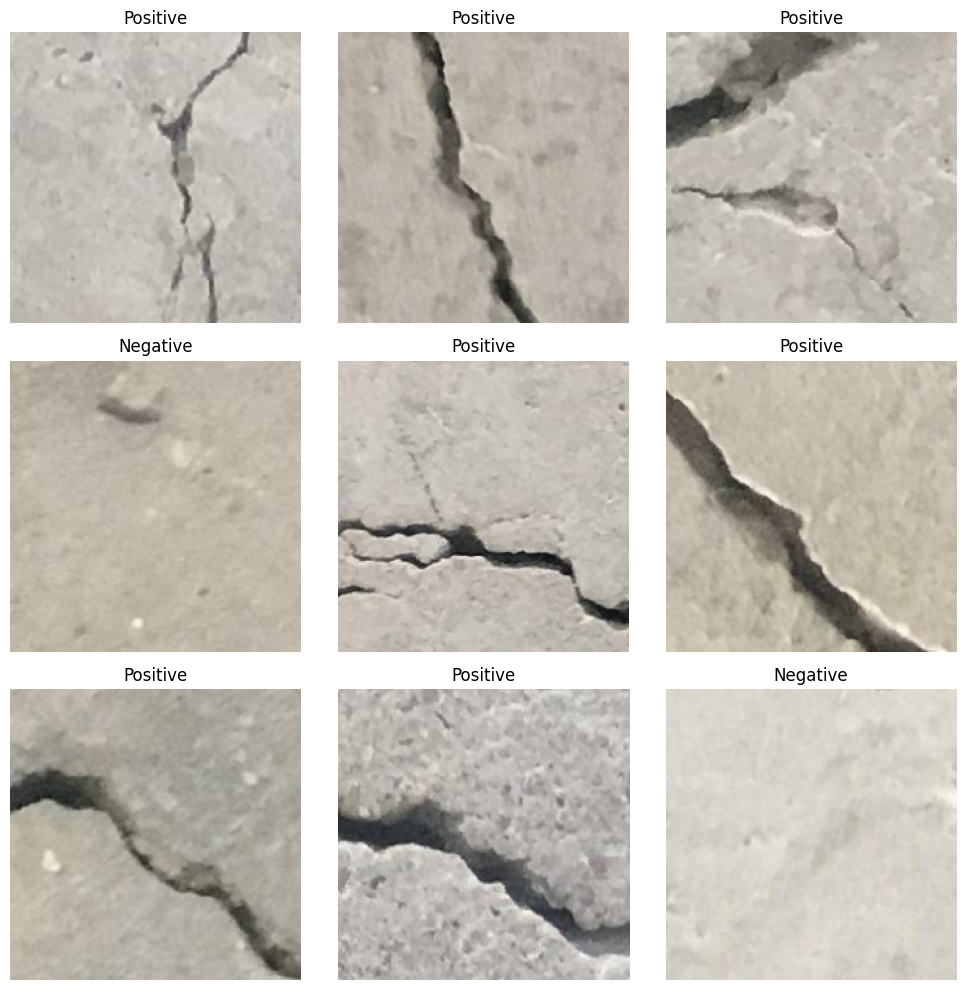

In [31]:
import matplotlib.pyplot as plt

print("Classes:", CLASS_NAMES)

for images, labels in train_ds.take(1):

    plt.figure(figsize=(10,10))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[labels[i].numpy()])

        plt.axis("off")

    plt.tight_layout()

plt.show()

## PHASE 2.3 — Build the EfficientNetB0 Model

In [32]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import callbacks

In [33]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

], name="augmentation")

In [34]:
base_model = tf.keras.applications.EfficientNetB0(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)

)

base_model.trainable = False

In [35]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(

    1,

    activation="sigmoid",

    dtype="float32"

)(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [36]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-3

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(name="auc"),

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall")

    ]

)

In [37]:
checkpoint = callbacks.ModelCheckpoint(

    os.path.join(

        OUTPUTS["models"],

        "efficientnet_head.keras"

    ),

    save_best_only=True,

    monitor="val_accuracy",

    mode="max"

)

earlystop = callbacks.EarlyStopping(

    monitor="val_loss",

    patience=4,

    restore_best_weights=True

)

reduce = callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)

csvlogger = callbacks.CSVLogger(

    os.path.join(

        OUTPUTS["logs"],

        "training_head.csv"

    )

)

In [38]:
history1 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    callbacks=[

        checkpoint,

        earlystop,

        reduce,

        csvlogger

    ]

)

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 114s 110ms/step - accuracy: 0.9910 - auc: 0.9992 - loss: 0.0263 - precision: 0.9925 - recall: 0.9894 - val_accuracy: 0.9992 - val_auc: 1.0000 - val_loss: 0.0032 - val_precision: 0.9987 - val_recall: 0.9997 - learning_rate: 0.0010
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9967 - auc: 0.9997 - loss: 0.0099 - precision: 0.9971 - recall: 0.9964 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0017 - val_precision: 0.9993 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 144s 107ms/step - accuracy: 0.9976 - auc: 0.9999 - loss: 0.0078 - precision: 0.9981 - recall: 0.9971 - val_accuracy: 0.9998 - val_auc: 1.0000 - val_loss: 0.0015 - val_precision: 0.9997 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 140s 105ms/step - accuracy: 0.9969 - auc: 0.9996 - loss: 0.0092 - precision: 0.9973 - recall: 0.9966 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0

In [39]:
base_model.trainable = True

In [40]:
for layer in base_model.layers[:-20]:

    layer.trainable = False

In [41]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-5

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(name="auc"),

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall")

    ]

)

In [42]:
history2 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    initial_epoch=history1.epoch[-1] + 1,

    callbacks=[

        checkpoint,

        earlystop,

        reduce,

        csvlogger

    ]

)

Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 121s 122ms/step - accuracy: 0.9923 - auc: 0.9992 - loss: 0.0246 - precision: 0.9905 - recall: 0.9940 - val_accuracy: 0.9985 - val_auc: 1.0000 - val_loss: 0.0041 - val_precision: 0.9987 - val_recall: 0.9983 - learning_rate: 1.0000e-05
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9959 - auc: 0.9997 - loss: 0.0131 - precision: 0.9962 - recall: 0.9957
Epoch 7: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
875/875 ━━━━━━━━━━━━━━━━━━━━ 101s 116ms/step - accuracy: 0.9964 - auc: 0.9998 - loss: 0.0116 - precision: 0.9966 - recall: 0.9961 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0.0032 - val_precision: 0.9997 - val_recall: 0.9990 - learning_rate: 1.0000e-05
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 142s 116ms/step - accuracy: 0.9959 - auc: 0.9996 - loss: 0.0122 - precision: 0.9969 - recall: 0.9949 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0.0029 - val_precision: 0.9997 - val_recall: 0.9990 - 

In [43]:
model.save(

    os.path.join(

        OUTPUTS["models"],

        "EfficientNetB0_Final.keras"

    )

)

print("Model Saved.")

Model Saved.


# PHASE 3 — Complete Evaluation Pipeline

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    log_loss
)

import seaborn as sns

In [45]:
best_model = tf.keras.models.load_model(
    os.path.join(
        OUTPUTS["models"],
        "efficientnet_head.keras"
    )
)

print("Best model loaded.")

Best model loaded.


In [46]:
y_true = []
y_prob = []

for images, labels in test_ds:

    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_prob.extend(predictions.flatten())

y_true = np.array(y_true)

y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions Completed")

Predictions Completed


In [47]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

roc_auc = roc_auc_score(y_true, y_prob)

pr_auc = average_precision_score(y_true, y_prob)

mcc = matthews_corrcoef(y_true, y_pred)

kappa = cohen_kappa_score(y_true, y_pred)

balanced_acc = balanced_accuracy_score(y_true, y_pred)

loss = log_loss(y_true, y_prob)

In [48]:
cm = confusion_matrix(y_true, y_pred)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)

sensitivity = TP / (TP + FN)

In [49]:
results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "Sensitivity",

        "Specificity",

        "F1 Score",

        "ROC AUC",

        "PR AUC",

        "Balanced Accuracy",

        "Matthews Corrcoef",

        "Cohen Kappa",

        "Log Loss"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        sensitivity,

        specificity,

        f1,

        roc_auc,

        pr_auc,

        balanced_acc,

        mcc,

        kappa,

        loss

    ]

})

display(results)

,Metric,Value
0,Accuracy,0.998496
1,Precision,0.997663
2,Recall,0.999331
3,Sensitivity,0.999331
4,Specificity,0.997662
5,F1 Score,0.998496
6,ROC AUC,0.999985
7,PR AUC,0.999984
8,Balanced Accuracy,0.998497
9,Matthews Corrcoef,0.996993


In [50]:
results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "Sensitivity",

        "Specificity",

        "F1 Score",

        "ROC AUC",

        "PR AUC",

        "Balanced Accuracy",

        "Matthews Corrcoef",

        "Cohen Kappa",

        "Log Loss"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        sensitivity,

        specificity,

        f1,

        roc_auc,

        pr_auc,

        balanced_acc,

        mcc,

        kappa,

        loss

    ]

})

display(results)

,Metric,Value
0,Accuracy,0.998496
1,Precision,0.997663
2,Recall,0.999331
3,Sensitivity,0.999331
4,Specificity,0.997662
5,F1 Score,0.998496
6,ROC AUC,0.999985
7,PR AUC,0.999984
8,Balanced Accuracy,0.998497
9,Matthews Corrcoef,0.996993


In [51]:
results.to_csv(

    os.path.join(

        OUTPUTS["metrics"],

        "test_metrics.csv"

    ),

    index=False

)

print("Metrics Saved")

Metrics Saved


In [52]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    digits=5

)

print(report)

with open(

    os.path.join(

        OUTPUTS["metrics"],

        "classification_report.txt"

    ),

    "w"

) as f:

    f.write(report)

              precision    recall  f1-score   support

    Negative    0.99933   0.99766   0.99850      2994
    Positive    0.99766   0.99933   0.99850      2990

    accuracy                        0.99850      5984
   macro avg    0.99850   0.99850   0.99850      5984
weighted avg    0.99850   0.99850   0.99850      5984



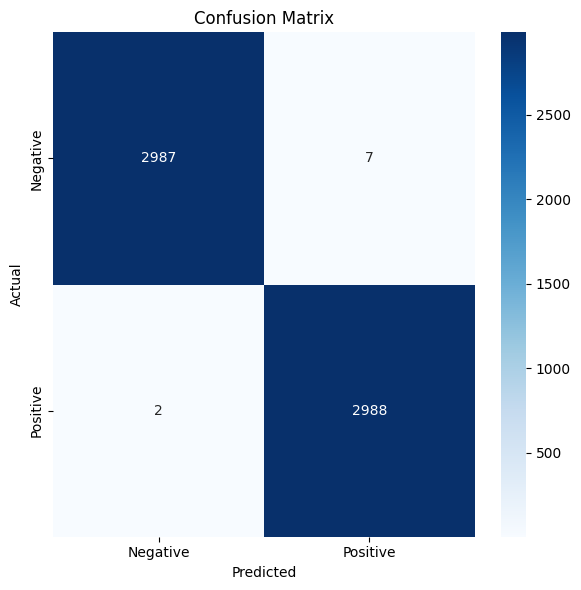

In [53]:
plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUTS["plots"],

        "confusion_matrix.png"

    ),

    dpi=600

)

plt.show()

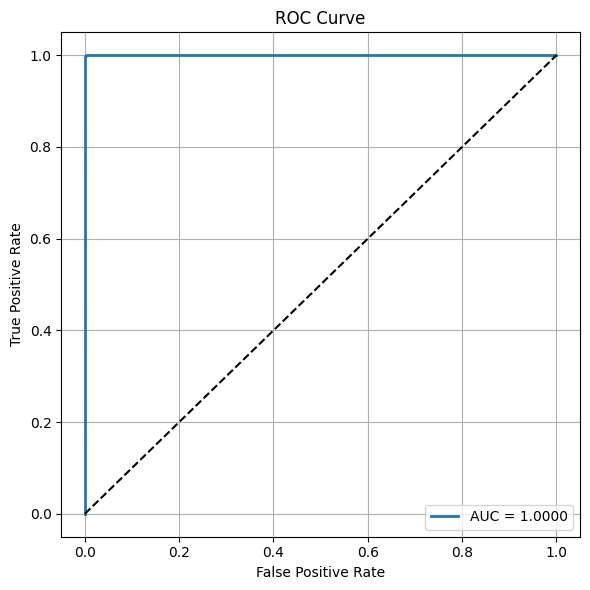

In [54]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUTS["plots"],

        "roc_curve.png"

    ),

    dpi=600

)

plt.show()

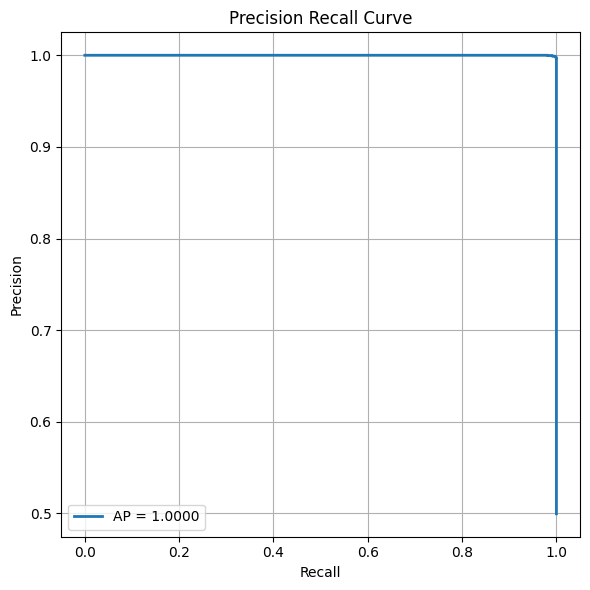

In [55]:
precision_curve, recall_curve, _ = precision_recall_curve(

    y_true,

    y_prob

)

plt.figure(figsize=(6,6))

plt.plot(

    recall_curve,

    precision_curve,

    linewidth=2,

    label=f"AP = {pr_auc:.4f}"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(

    os.path.join(

        OUTPUTS["plots"],

        "precision_recall_curve.png"

    ),

    dpi=600

)

plt.show()

In [56]:
prediction_df = pd.DataFrame({

    "Actual":y_true,

    "Probability":y_prob,

    "Prediction":y_pred

})

prediction_df.to_csv(

    os.path.join(

        OUTPUTS["predictions"],

        "test_predictions.csv"

    ),

    index=False

)

print("Predictions Saved")

Predictions Saved


# PHASE 4 — Cross-Dataset Validation

In [57]:
archive30_ds = tf.keras.utils.image_dataset_from_directory(

    "/content/datasets/Dataset/archive 15000+15000=30000",

    shuffle=False,

    image_size=(224,224),

    batch_size=32

).prefetch(tf.data.AUTOTUNE)

Found 30000 files belonging to 2 classes.


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_dataset(model, dataset, invert_labels=False):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_prob.extend(preds.flatten())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    if invert_labels:
        y_true = 1 - y_true

    y_pred = (y_prob >= 0.5).astype(int)

    return {

        "Accuracy": accuracy_score(y_true, y_pred),

        "Precision": precision_score(y_true, y_pred),

        "Recall": recall_score(y_true, y_pred),

        "F1": f1_score(y_true, y_pred),

        "ROC_AUC": roc_auc_score(y_true, y_prob)

    }

In [69]:
archive30_results = evaluate_dataset(

    best_model,

    archive30_ds

)

archive30_results

{'Accuracy': 0.9540666666666666,
 'Precision': 0.9754956716001117,
 'Recall': 0.9315333333333333,
 'F1': 0.9530077752012004,
 'ROC_AUC': np.float64(0.9921951266666668)}

In [70]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

decks_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/datasets/Dataset/archive_dpw/Decks",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

walls_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/datasets/Dataset/archive_dpw/Walls",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

pavements_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/datasets/Dataset/archive_dpw/Pavements",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
).prefetch(tf.data.AUTOTUNE)

print("All DPW datasets loaded successfully.")

Found 13620 files belonging to 2 classes.
Found 18138 files belonging to 2 classes.
Found 24334 files belonging to 2 classes.
All DPW datasets loaded successfully.


In [71]:
decks_results = evaluate_dataset(
    best_model,
    decks_ds,
    invert_labels=True
)

walls_results = evaluate_dataset(
    best_model,
    walls_ds,
    invert_labels=True
)

pavements_results = evaluate_dataset(
    best_model,
    pavements_ds,
    invert_labels=True
)

print("Decks")
print(decks_results)

print("\nWalls")
print(walls_results)

print("\nPavements")
print(pavements_results)

Decks
{'Accuracy': 0.8564610866372981, 'Precision': 0.5303819444444444, 'Recall': 0.3017283950617284, 'F1': 0.3846395971041863, 'ROC_AUC': np.float64(0.7780923024505029)}

Walls
{'Accuracy': 0.8181717940235969, 'Precision': 0.7995666305525461, 'Recall': 0.19163853544533888, 'F1': 0.3091746962714705, 'ROC_AUC': np.float64(0.7459597086015569)}

Pavements
{'Accuracy': 0.8405934083997698, 'Precision': 0.3638894838295138, 'Recall': 0.651457055214724, 'F1': 0.46695066648344097, 'ROC_AUC': np.float64(0.8498216546260199)}


In [72]:
comparison = pd.DataFrame({

    "Dataset":[
        "Archive40K Test",
        "Archive30K",
        "Decks",
        "Walls",
        "Pavements"
    ],

    "Accuracy":[
        accuracy,
        archive30_results["Accuracy"],
        decks_results["Accuracy"],
        walls_results["Accuracy"],
        pavements_results["Accuracy"]
    ],

    "Precision":[
        precision,
        archive30_results["Precision"],
        decks_results["Precision"],
        walls_results["Precision"],
        pavements_results["Precision"]
    ],

    "Recall":[
        recall,
        archive30_results["Recall"],
        decks_results["Recall"],
        walls_results["Recall"],
        pavements_results["Recall"]
    ],

    "F1":[
        f1,
        archive30_results["F1"],
        decks_results["F1"],
        walls_results["F1"],
        pavements_results["F1"]
    ],

    "ROC_AUC":[
        roc_auc,
        archive30_results["ROC_AUC"],
        decks_results["ROC_AUC"],
        walls_results["ROC_AUC"],
        pavements_results["ROC_AUC"]
    ]

})

display(comparison)

comparison.to_csv(
    os.path.join(
        OUTPUTS["metrics"],
        "cross_dataset_validation.csv"
    ),
    index=False
)

print("Cross-dataset validation results saved.")

,Dataset,Accuracy,Precision,Recall,F1,ROC_AUC
0,Archive40K Test,0.998496,0.997663,0.999331,0.998496,0.999985
1,Archive30K,0.954067,0.975496,0.931533,0.953008,0.992195
2,Decks,0.856461,0.530382,0.301728,0.384640,0.778092
3,Walls,0.818172,0.799567,0.191639,0.309175,0.745960
4,Pavements,0.840593,0.363889,0.651457,0.466951,0.849822


Cross-dataset validation results saved.


In [73]:
1+1

2

# PHASE 5 — Ablation Study

In [74]:
from tensorflow.keras import layers
from tensorflow.keras import callbacks

def build_model(use_augmentation=True):

    inputs = tf.keras.Input(shape=(224,224,3))

    x = inputs

    if use_augmentation:

        x = data_augmentation(x)

    x = tf.keras.applications.efficientnet.preprocess_input(x)

    base = tf.keras.applications.EfficientNetB0(

        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)

    )

    base.trainable = False

    x = base(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(

        optimizer=tf.keras.optimizers.Adam(1e-3),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]

    )

    return model, base

In [80]:
def quick_test(model):

    results = model.evaluate(
        test_ds,
        verbose=0
    )

    metric_names = model.metrics_names

    metric_dict = dict(zip(metric_names, results))

    acc = metric_dict["accuracy"]
    auc = metric_dict["auc"]

    return acc, auc

In [76]:
model_a1, base_a1 = build_model(False)

model_a1.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    verbose=1

)

a1_acc, a1_auc = quick_test(model_a1)

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 97s 63ms/step - accuracy: 0.9894 - auc: 0.9993 - loss: 0.0287 - val_accuracy: 0.9992 - val_auc: 1.0000 - val_loss: 0.0027
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.9971 - auc: 0.9997 - loss: 0.0091 - val_accuracy: 0.9995 - val_auc: 1.0000 - val_loss: 0.0015
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.9979 - auc: 0.9998 - loss: 0.0069 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0010
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9976 - auc: 0.9998 - loss: 0.0067 - val_accuracy: 0.9995 - val_auc: 1.0000 - val_loss: 0.0011
Epoch 5/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0057 - val_accuracy: 0.9998 - val_auc: 1.0000 - val_loss: 0.0011


In [77]:
model_a2, base_a2 = build_model(True)

model_a2.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    verbose=1

)

a2_acc, a2_auc = quick_test(model_a2)

Epoch 1/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 105s 107ms/step - accuracy: 0.9911 - auc: 0.9994 - loss: 0.0255 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0.0025
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 90s 103ms/step - accuracy: 0.9969 - auc: 0.9997 - loss: 0.0096 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0015
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 92s 105ms/step - accuracy: 0.9975 - auc: 0.9996 - loss: 0.0090 - val_accuracy: 0.9995 - val_auc: 1.0000 - val_loss: 0.0016
Epoch 4/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 92s 106ms/step - accuracy: 0.9973 - auc: 0.9997 - loss: 0.0086 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0.0013
Epoch 5/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.9977 - auc: 0.9997 - loss: 0.0073 - val_accuracy: 0.9993 - val_auc: 1.0000 - val_loss: 0.0017


In [78]:
model_a3, base_a3 = build_model(False)

model_a3.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5,

    verbose=0

)

base_a3.trainable = True

for layer in base_a3.layers[:-20]:

    layer.trainable = False

model_a3.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]

)

model_a3.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    initial_epoch=5,

    verbose=1

)

a3_acc, a3_auc = quick_test(model_a3)

Epoch 6/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - accuracy: 0.9930 - auc: 0.9992 - loss: 0.0218 - val_accuracy: 0.9990 - val_auc: 1.0000 - val_loss: 0.0030
Epoch 7/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 64s 66ms/step - accuracy: 0.9964 - auc: 0.9998 - loss: 0.0106 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0018
Epoch 8/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 49s 55ms/step - accuracy: 0.9977 - auc: 0.9997 - loss: 0.0074 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0017
Epoch 9/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9975 - auc: 0.9998 - loss: 0.0072 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0016
Epoch 10/10
875/875 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9981 - auc: 0.9997 - loss: 0.0066 - val_accuracy: 0.9997 - val_auc: 1.0000 - val_loss: 0.0015


In [82]:
results = model_a4.evaluate(test_ds, verbose=0)

print("Metric Names:")
print(model_a4.metrics_names)

print("\nResults:")
print(results)

Metric Names:
['loss', 'compile_metrics']

Results:
[0.006487010512501001, 0.9984959959983826, 0.9996466040611267, 0.9986585974693298, 0.9983238577842712]


In [83]:
results = model_a4.evaluate(test_ds, verbose=0)

a4_acc = results[1]
a4_auc = results[2]

print(f"A4 Accuracy : {a4_acc:.6f}")
print(f"A4 ROC AUC  : {a4_auc:.6f}")

A4 Accuracy : 0.998496
A4 ROC AUC  : 0.999645


In [84]:
ablation = pd.DataFrame({

    "Configuration":[

        "No Augmentation + No Fine-Tuning",

        "Augmentation Only",

        "Fine-Tuning Only",

        "Augmentation + Fine-Tuning"

    ],

    "Accuracy":[

        a1_acc,

        a2_acc,

        a3_acc,

        a4_acc

    ],

    "ROC_AUC":[

        a1_auc,

        a2_auc,

        a3_auc,

        a4_auc

    ]

})

display(ablation)

ablation.to_csv(

    os.path.join(

        OUTPUTS["metrics"],

        "ablation_study.csv"

    ),

    index=False

)

print("Ablation study saved.")

,Configuration,Accuracy,ROC_AUC
0,No Augmentation + No Fine-Tuning,0.998663,0.999661
1,Augmentation Only,0.998162,0.999493
2,Fine-Tuning Only,0.998997,0.999659
3,Augmentation + Fine-Tuning,0.998496,0.999645


Ablation study saved.
